Cài đặt thư viện và cấu hình

In [2]:
import os
import shutil
import random
import kagglehub
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# --- CẤU HÌNH THÔNG SỐ TOÀN CỤC ---
EPOCHS = 40
BATCH_SIZE = 32
IMG_SIZE = (150, 150)
BASE_DIR = '/content/my_dataset'

#PHẦN 1: CHUẨN BỊ VÀ CÂN BẰNG DỮ LIỆU
Tải dataset gốc từ Kaggle. Dữ liệu thực tế thường bị mất cân bằng. Thuật toán dưới đây sẽ tự động tìm thư mục ảnh, lọc các file lỗi và chia đều số lượng ảnh cho mỗi lớp theo chuẩn: **400 Train - 100 Valid - 100 Test**

In [3]:
print("1. Đang tải dữ liệu từ Kaggle...")
path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")

# Tự động tìm thư mục chứa ảnh
true_train_path = ""
for root, dirs, files in os.walk(path):
    if "Train" in dirs and len(os.listdir(os.path.join(root, "Train"))) > 0:
        true_train_path = os.path.join(root, "Train")
        break

# Dọn rác thư mục cũ
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = sorted([d for d in os.listdir(true_train_path) if os.path.isdir(os.path.join(true_train_path, d))])[:10]
print("2. Đang phân chia ảnh (400-100-100)...")
for cls in classes:
    for split in ['Train', 'Valid', 'Test']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

    src = os.path.join(true_train_path, cls)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(42)
    random.shuffle(imgs)
    for i, f in enumerate(imgs[:600]):
        if i < 400: dest = 'Train'
        elif i < 500: dest = 'Valid'
        else: dest = 'Test'
        shutil.copy(os.path.join(src, f), os.path.join(BASE_DIR, dest, cls, f))

# Nạp vào tf.data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Valid'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

1. Đang tải dữ liệu từ Kaggle...
Using Colab cache for faster access to the 'fast-food-classification-dataset' dataset.
2. Đang phân chia ảnh (400-100-100)...
Found 4000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


#PHẦN 2: MÔ HÌNH CƠ BẢN- BASELINE CNN - PHASE 1
Xây dựng mạng CNN thuần túy, độ sâu vừa phải, KHÔNG có tính năng Tăng cường dữ liệu. Mô hình này đóng vai trò làm điểm chuẩn để chứng minh tính hiệu quả của Phase 2.

🚀 Huấn luyện Mô hình Cơ bản (Phase 1) - 40 epochs...
Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1375 - loss: 2.2799 - val_accuracy: 0.1640 - val_loss: 2.2548
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.2002 - loss: 2.1758 - val_accuracy: 0.2000 - val_loss: 2.1943
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.2195 - loss: 2.1281 - val_accuracy: 0.2050 - val_loss: 2.1525
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2470 - loss: 2.0931 - val_accuracy: 0.2300 - val_loss: 2.1207
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2625 - loss: 2.0551 - val_accuracy: 0.2450 - val_loss: 2.1087
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2775 - loss: 2.0269 - val_accuracy: 0.2480 - val_loss: 2.0862
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2870 - loss: 2.0137 - val_accuracy: 0.2800 - val_loss: 2.0321
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s

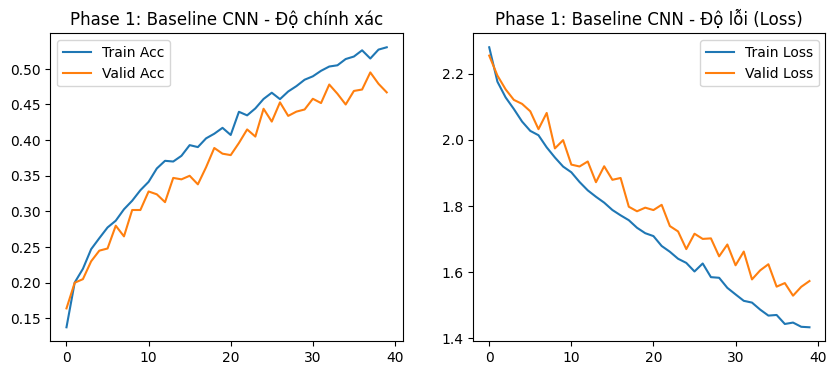

In [4]:
def build_baseline():
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),

        layers.GlobalAveragePooling2D(name="feature_layer"),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print(f"🚀 Huấn luyện Mô hình Cơ bản (Phase 1) - {EPOCHS} epochs...")
model_p1 = build_baseline()
history_p1 = model_p1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# File kết quả train
model_p1.save('baseline_model_p1.keras')

# Dùng để vẽ biểu đồ
def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Valid Acc')
    plt.title(f'{title} - Độ chính xác')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.title(f'{title} - Độ lỗi (Loss)')
    plt.legend()
    plt.show()

plot_history(history_p1, "Phase 1: Baseline CNN")

#PHẦN 3: PHÂN CỤM DỮ LIỆU ĐỂ PHÂN TÍCH - CLUSTERING
Sử dụng mô hình Phase 1 để trích xuất đặc trưng hình ảnh, sau đó dùng thuật toán K-Means gom cụm thành 10 nhóm. Kỹ thuật này hỗ trợ tìm ra các bức ảnh gây nhiễu.

In [5]:
print("📊 Trích xuất Vector và chạy K-Means...")
feature_extractor = models.Sequential(model_p1.layers[:-1])

image_batches = []
for imgs, labs in train_ds.take(20):
    image_batches.append(imgs)
images_only = np.concatenate(image_batches, axis=0)

# Dự đoán
features = feature_extractor.predict(images_only, verbose=0)
features_cos = normalize(features)

kmeans = KMeans(n_clusters=10, random_state=42).fit(features_cos)

# Xuất file K-Means
joblib.dump(kmeans, 'kmeans_model.pkl')

📊 Trích xuất Vector và chạy K-Means...


['kmeans_model.pkl']

#PHẦN 4: MODULE TĂNG CƯỜNG DỮ LIỆU & PHASE 2
Định nghĩa Module Augmentation hoạt động theo cơ chế **"On-the-fly"**. Module này được ghép vào một mạng Deep CNN sâu hơn, tích hợp Dropout để tránh tình trạng Học vẹt.

🚀 Huấn luyện Mô hình Nâng cao (Phase 2) - 40 epochs...
Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.1152 - loss: 2.2950 - val_accuracy: 0.1320 - val_loss: 2.2843
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.1427 - loss: 2.2590 - val_accuracy: 0.1550 - val_loss: 2.2517
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.1577 - loss: 2.2421 - val_accuracy: 0.1560 - val_loss: 2.2312
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1562 - loss: 2.2271 - val_accuracy: 0.1670 - val_loss: 2.2100
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.1815 - loss: 2.2071 - val_accuracy: 0.1920 - val_loss: 2.2167
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.1807 - loss: 2.1876 - val_accuracy: 0.2040 - val_loss: 2.2095
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.1857 - loss: 2.1818 - val_accuracy: 0.2200 - val_loss: 2.1772
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7

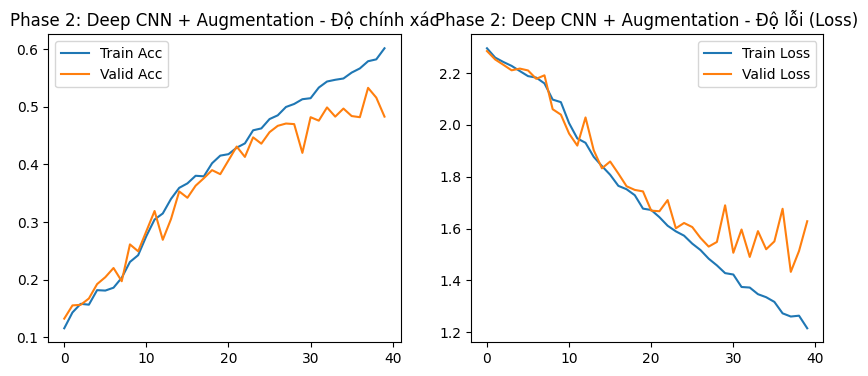

In [6]:
# 1. MODULE TĂNG CƯỜNG (DÙNG CHUNG)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="module_tang_cuong")

# 2. XÂY DỰNG DEEP CNN
model_p2 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_p2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(f"🚀 Huấn luyện Mô hình Nâng cao (Phase 2) - {EPOCHS} epochs...")
history_p2 = model_p2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Xuất file train
model_p2.save('augmented_model_p2.keras')

plot_history(history_p2, "Phase 2: Deep CNN + Augmentation")